In [1]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from torchvision.utils import make_grid
from tqdm import trange, tqdm
from geometry_tools import lerp
from conditional_gmm import ConditionalGMM
from posterior_manifold import FisherLogPosteriorManifold
from conformal_ebm import optimize_ebm_geodesic
from utils import categorical_entropy, get_random_image, get_random_images, get_random_images_of_classes
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
import torch.distributions as D

transform = v2.Compose([
    v2.Resize((64, 64), interpolation=v2.InterpolationMode.BILINEAR),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
dataset = torchvision.datasets.CelebA(root='datasets', split='all', transform=transform, download=False)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=4)

def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

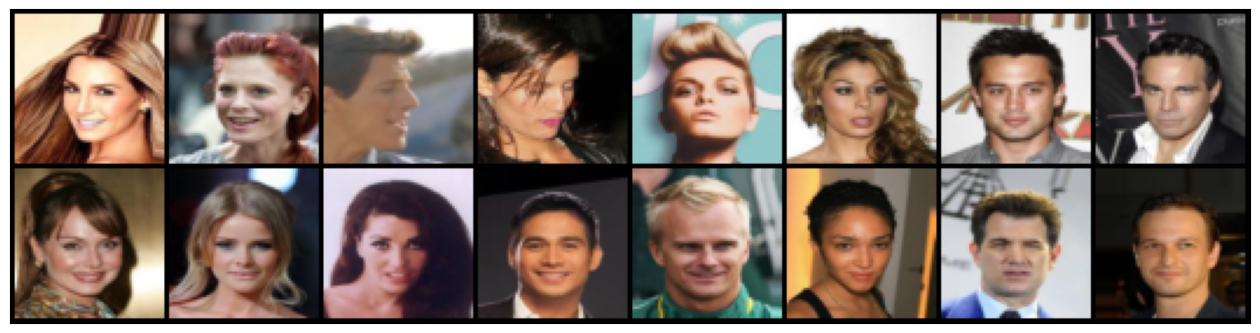

In [2]:
imgs, labels = next(dataloader.__iter__())
politician = imgs[14]
show_img(make_grid(imgs), figsize=(16, 8))

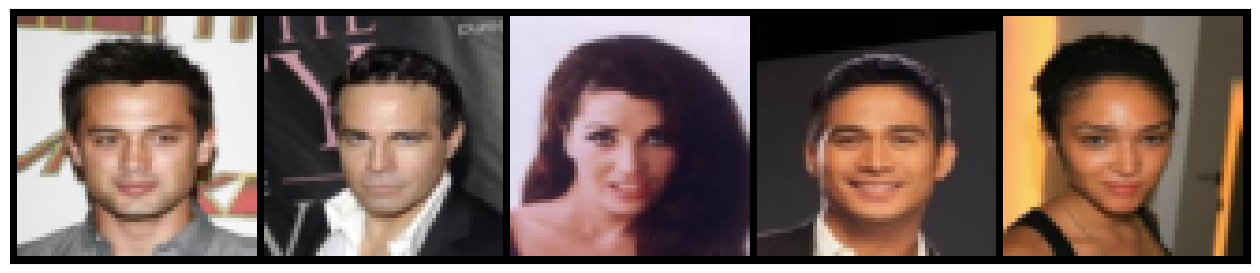

In [3]:
show_img(make_grid(imgs[labels[:, 8].bool()]), figsize=(16, 8))

In [4]:
from pretrained_models import CelebAVAE
vae = CelebAVAE(n_latent=64)


/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/repos/torch_vae/model.py:288: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(fname

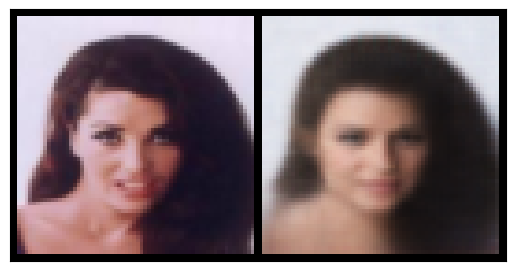

In [5]:
with torch.no_grad():
    test_img = imgs[10]
    reconstructed = vae.reconstruct(test_img)
    show_img(make_grid(torch.stack((test_img, reconstructed))))

In [6]:
attribute_names = ["5_o_Clock_Shadow", "Arched_Eyebrows", "Attractive", "Bags_Under_Eyes", "Bald", "Bangs", "Big_Lips", "Big_Nose", "Black_Hair", "Blond_Hair", "Blurry", "Brown_Hair", "Bushy_Eyebrows", "Chubby", "Double_Chin", "Eyeglasses", "Goatee", "Gray_Hair", "Heavy_Makeup", "High_Cheekbones", "Male", "Mouth_Slightly_Open", "Mustache", "Narrow_Eyes", "No_Beard", "Oval_Face", "Pale_Skin", "Pointy_Nose", "Receding_Hairline", "Rosy_Cheeks", "Sideburns", "Smiling", "Straight_Hair", "Wavy_Hair", "Wearing_Earrings", "Wearing_Hat", "Wearing_Lipstick", "Wearing_Necklace", "Wearing_Necktie", "Young"]

In [7]:
from matplotlib.ticker import MultipleLocator
def show_latent_curve(curve: torch.Tensor, title=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=(12, 1.25))
        ax = fig.add_subplot()
    img = make_grid(vae.decode(curve), nrow=curve.shape[0])
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray', extent=(0, 1, 0, 1/len(curve)))
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    # ax.set_xlim(0, 1)
    if title: ax.set_title(title)

## Simple GMM

In [13]:
gmm = ConditionalGMM(n_dim=64, n_classes=40)
with torch.no_grad():
    for images, class_labels in tqdm(dataloader, desc='Fitting GMM'):
        gmm.update_multiple(vae.encode(images.cuda()), class_labels.cuda())
    gmm.fit()

Fitting GMM: 100%|██████████| 12663/12663 [04:53<00:00, 43.21it/s]


In [27]:
M = FisherLogPosteriorManifold(gmm.log_posterior)

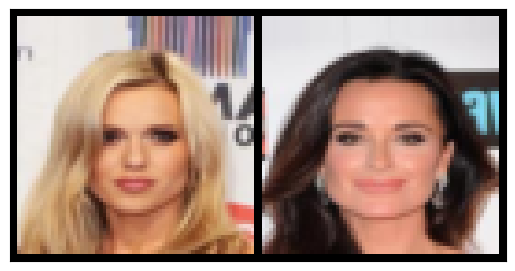

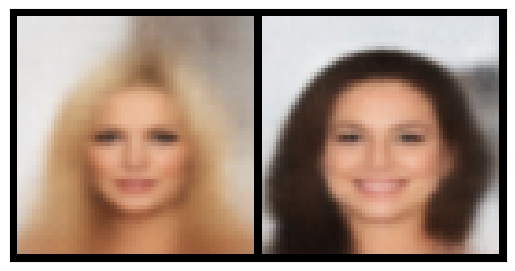

In [48]:
random_imgs =get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [00:44<00:00, 223.01it/s, loss=0.407]


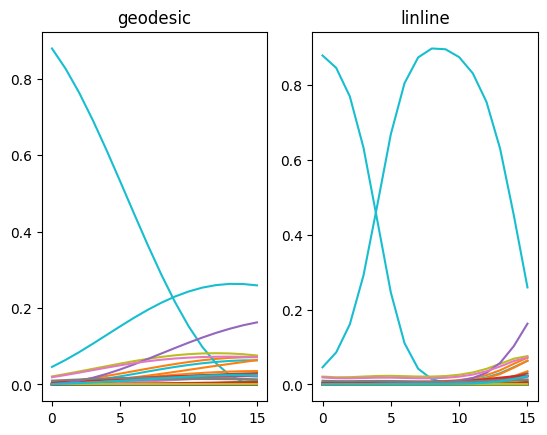

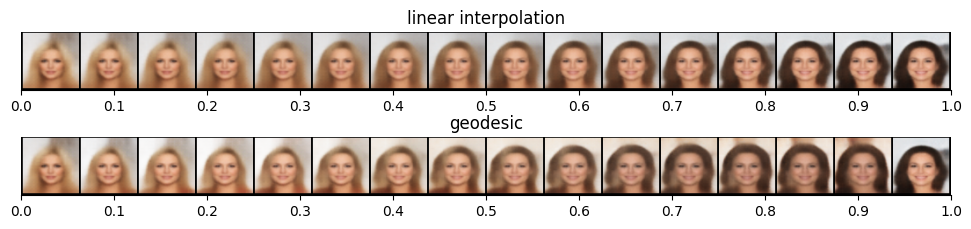

In [49]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = gmm.posterior(geodesic.cuda()).cpu()
    post_lin = gmm.posterior(linline.cuda()).cpu()
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

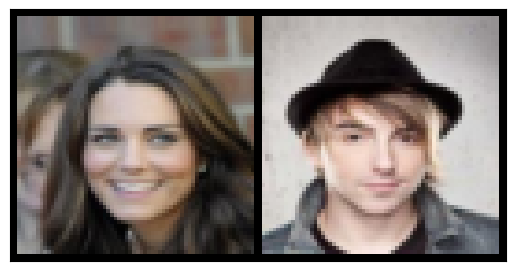

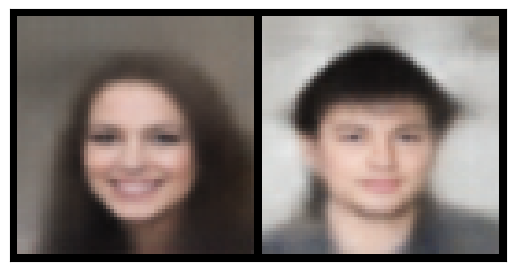

In [62]:
random_imgs = get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 10000/10000 [00:42<00:00, 234.94it/s, loss=0.639]


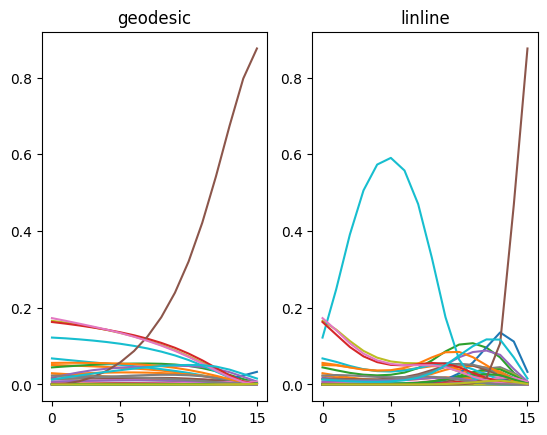

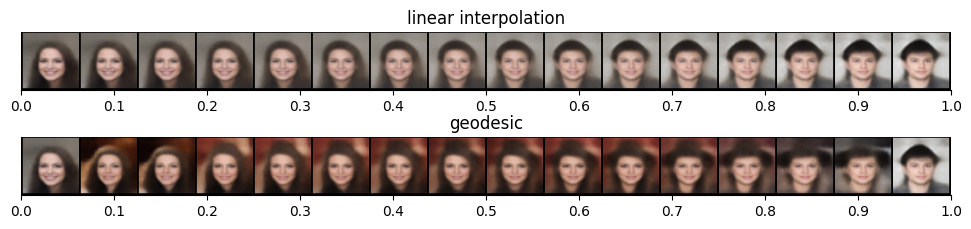

In [63]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = gmm.posterior(geodesic.cuda()).cpu()
    post_lin = gmm.posterior(linline.cuda()).cpu()
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

## Nested GMM

### fitting GMMs

In [66]:
# extracting digits separately
gmms = []
bigger_loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)
for i, attr_name in tqdm(enumerate(attribute_names), desc='Fitting atribute GMMS', position=0):
    digit_samples = np.array([[], [], [], [], [], [], [], [],[], [], [], [], [], [], [], [],[], [], [], [], [], [], [], [],[], [], [], [], [], [], [], [],[], [], [], [], [], [], [], [],[], [], [], [], [], [], [], [],[], [], [], [], [], [], [], [],[], [], [], [], [], [], [], [],]).T 
    with torch.no_grad():
        for images, class_labels in tqdm(bigger_loader, desc=attr_name, position=1, leave=False):
            if torch.any(class_labels[:, i]):
                digit_samples = np.concatenate((digit_samples, vae.encode(images[class_labels[:, i].bool()]).numpy()))
    new_gmm = GaussianMixture(n_components=16, covariance_type='diag',verbose=True, init_params='k-means++', max_iter=10000).fit(digit_samples)
    gmms.append(new_gmm)

Fitting atribute GMMS: 0it [00:00, ?it/s]

Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40


Fitting atribute GMMS: 1it [01:17, 77.12s/it]

Initialization converged.


Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60


...

Initialization 0
  Iteration 10
  Iteration 20


Fitting atribute GMMS: 39it [51:00, 77.31s/it]

  Iteration 30
Initialization converged.


Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
Initialization converged.


Fitting atribute GMMS: 40it [52:29, 78.75s/it]


### setting up the posterior manifold

In [67]:
torch.save(gmms, 'trained_checkpoints/celeba_nested_gmm.pt')

In [8]:
gmms = torch.load('trained_checkpoints/celeba_nested_gmm.pt')

/tmp/user/5678/ipykernel_1877395/82389919.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gmms = torch.load('trained_checkpoints/celeba_nested_gmm.pt')


In [9]:
gmms_torch = [D.MixtureSameFamily(
    mixture_distribution=D.Categorical(torch.as_tensor(gm.weights_, device='cuda', dtype=torch.float32)),
    component_distribution=D.MultivariateNormal(
        loc=torch.as_tensor(gm.means_, device='cuda', dtype=torch.float32),
        covariance_matrix=torch.as_tensor(gm.covariances_[..., None] * np.eye(64), device='cuda', dtype=torch.float32)
    )
) for gm in gmms]

In [10]:
bigger_loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)
attribute_counts = torch.zeros(40)
for _, labels in bigger_loader:
    for i in range(40):
        attribute_counts[i] += (labels[:, i]).sum()
log_prior = (torch.log(attribute_counts) - torch.log(attribute_counts.sum())).cuda()

In [11]:
def log_posterior(x: torch.Tensor) -> torch.Tensor:
    cond_log_likelihoods = torch.stack([
        gm.log_prob(x) for gm in gmms_torch
    ], dim=-1) + log_prior
    return cond_log_likelihoods - torch.logsumexp(cond_log_likelihoods, dim=-1, keepdim=True)

In [12]:
def log_likelihood(x: torch.Tensor) -> torch.Tensor:
    cond_log_likelihoods = torch.stack([
        gm.log_prob(x) for gm in gmms_torch
    ], dim=-1) + log_prior
    return torch.logsumexp(cond_log_likelihoods, dim=-1)

<BarContainer object of 40 artists>

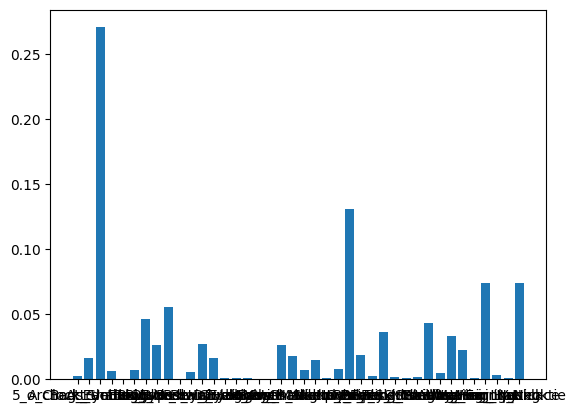

In [13]:
with torch.no_grad():
    test_img_posterior = torch.exp(log_posterior(vae.encode(test_img.cuda()))).cpu()
plt.bar(attribute_names, test_img_posterior)

In [14]:
def get_random_image_of_class(dataset, label: int):
    loader = DataLoader(dataset, batch_size=2, shuffle=True)
    itr = iter(loader)
    while True:
        imgs, lb = next(itr)
        if torch.any(lb[:, label]):
            return imgs[lb[:, label].argmax()]

def get_random_images_of_classes(dataset, labels: list[int]) -> torch.Tensor:
    return torch.stack([get_random_image_of_class(dataset, lb) for lb in labels])

In [15]:
M = FisherLogPosteriorManifold(log_posterior)

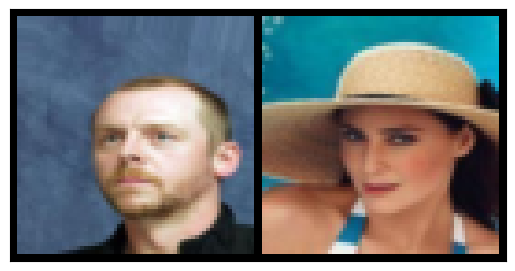

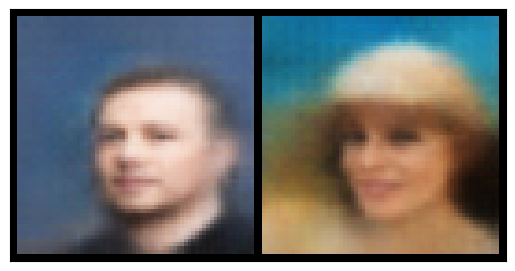

In [16]:
random_imgs = get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 1000/1000 [00:53<00:00, 18.82it/s, loss=0.152]


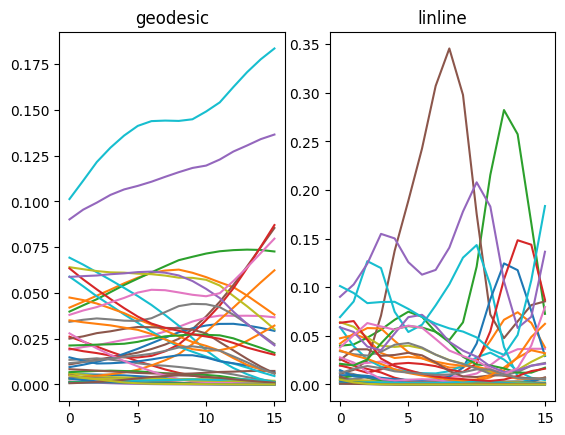

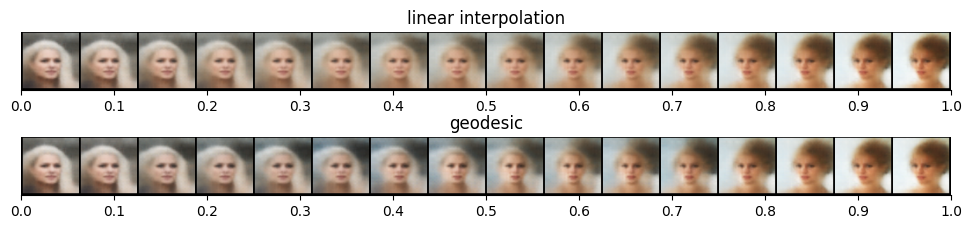

In [131]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

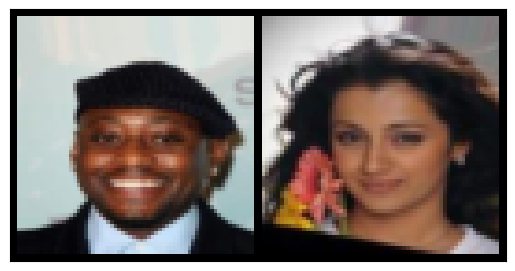

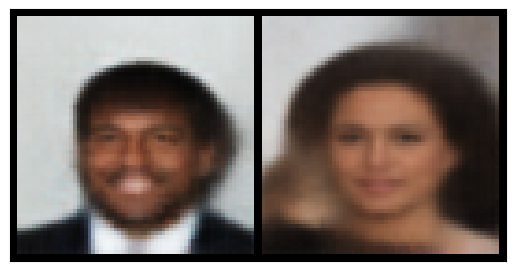

In [22]:
random_imgs = get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 1000/1000 [00:54<00:00, 18.32it/s, loss=0.426]


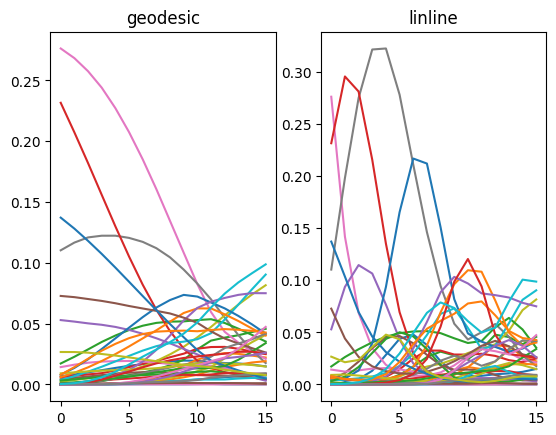

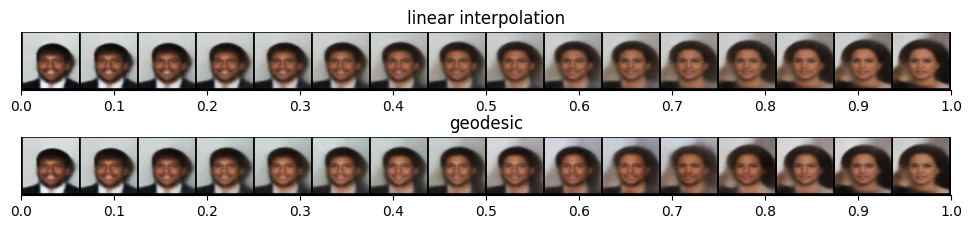

In [23]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_geo)
axl.set_title('geodesic')
axr.plot(post_lin)
axr.set_title('linline')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

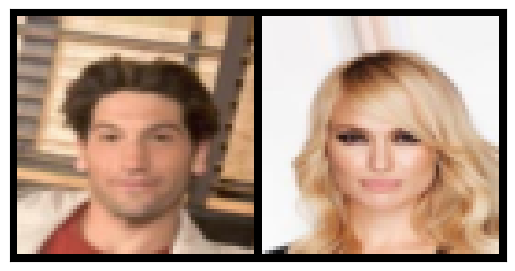

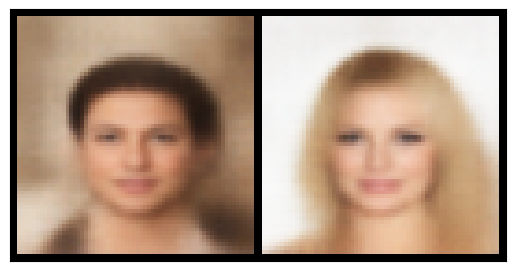

In [25]:
random_imgs = get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 1000/1000 [00:53<00:00, 18.70it/s, loss=0.273]


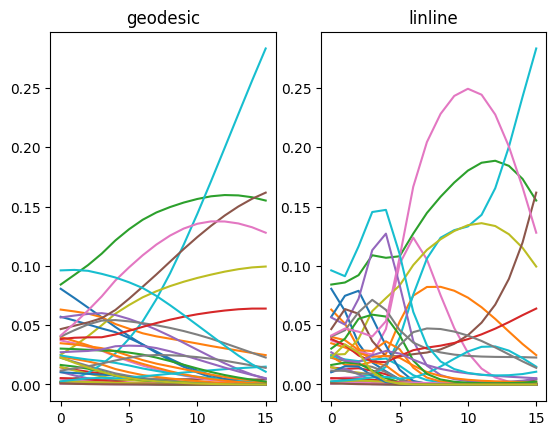

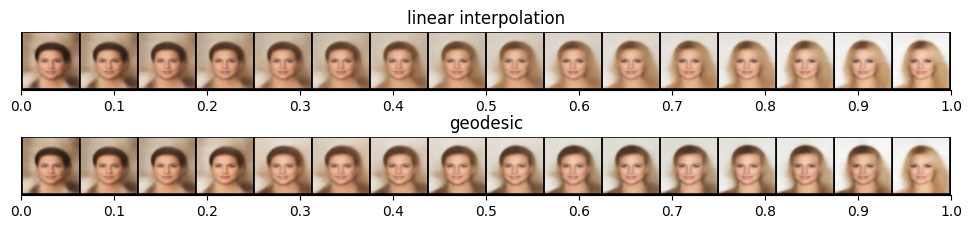

In [ ]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_lin)
axl.set_title('linear')
axr.plot(post_geo)
axr.set_title('geodesic')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

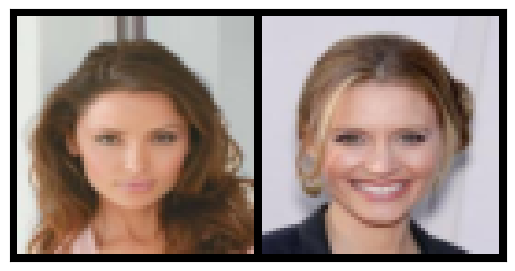

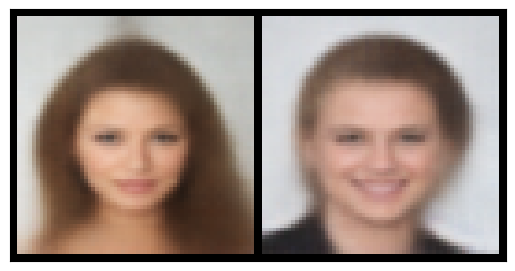

In [37]:
random_imgs = get_random_images(dataset, n=2) #type:ignore
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 1000/1000 [00:53<00:00, 18.72it/s, loss=0.257]


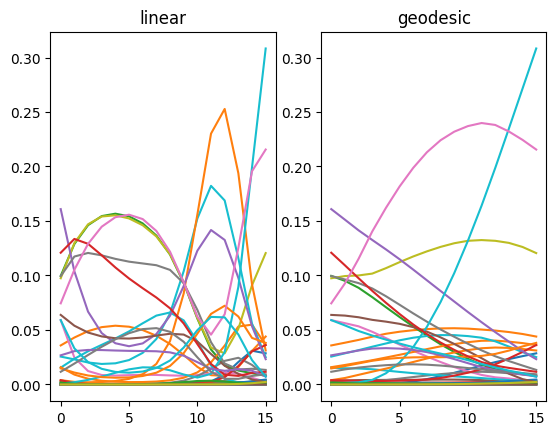

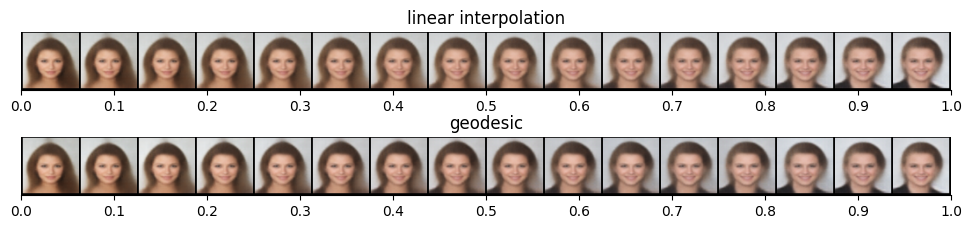

In [38]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_lin)
axl.set_title('linear')
axr.plot(post_geo)
axr.set_title('geodesic')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

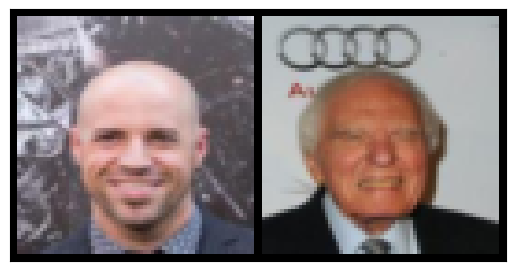

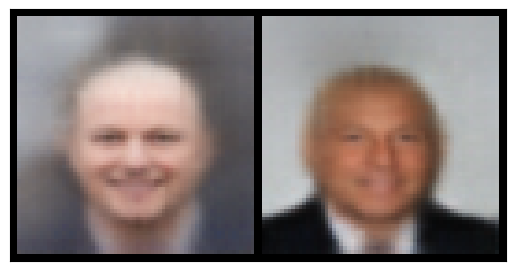

In [34]:
random_imgs = get_random_images_of_classes(dataset, [4, 4])
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 1000/1000 [00:54<00:00, 18.34it/s, loss=0.238]


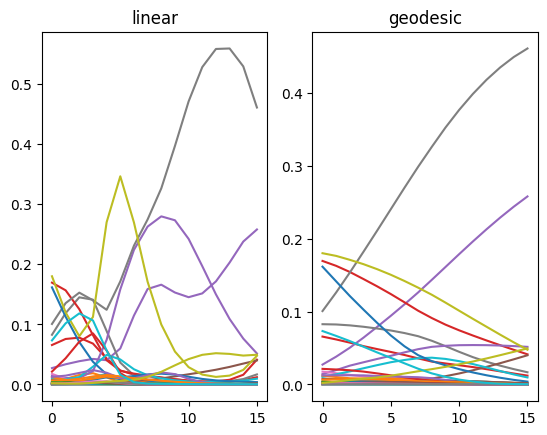

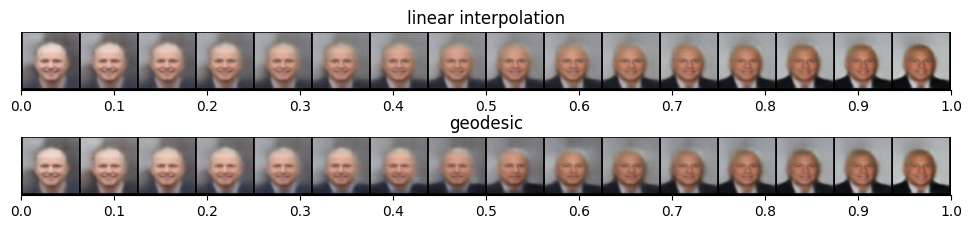

In [35]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_lin)
axl.set_title('linear')
axr.plot(post_geo)
axr.set_title('geodesic')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

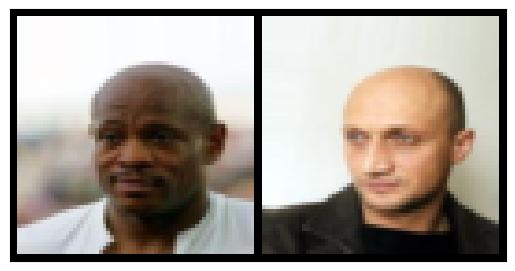

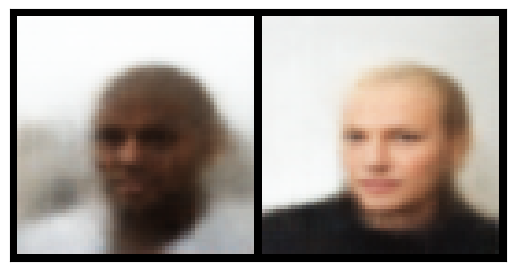

In [46]:
random_imgs = get_random_images_of_classes(dataset, [4, 4])
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing geodesic: 100%|██████████| 1000/1000 [00:53<00:00, 18.81it/s, loss=0.203]


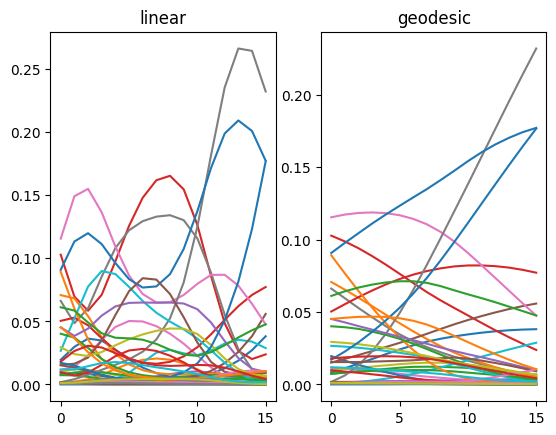

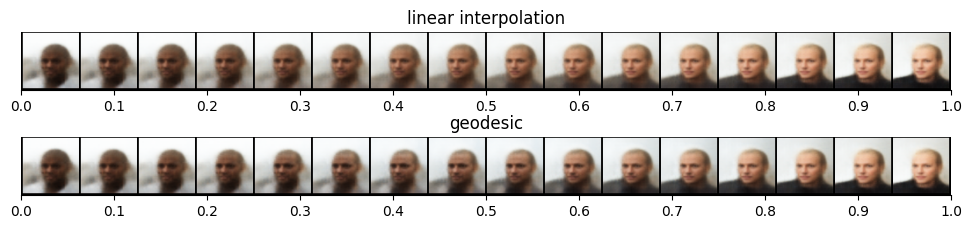

In [47]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
_, (axl, axr) = plt.subplots(1, 2)
axl.plot(post_lin)
axl.set_title('linear')
axr.plot(post_geo)
axr.set_title('geodesic')
plt.show()
_, (axu, axb) = plt.subplots(2, 1, figsize=(12, 2.5))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(geodesic, 'geodesic', ax=axb)
plt.show()

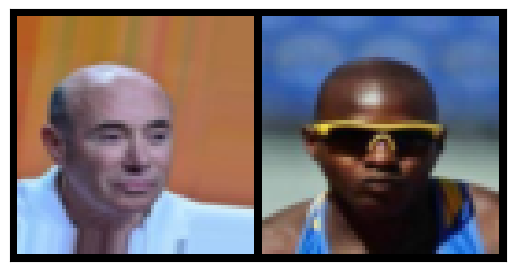

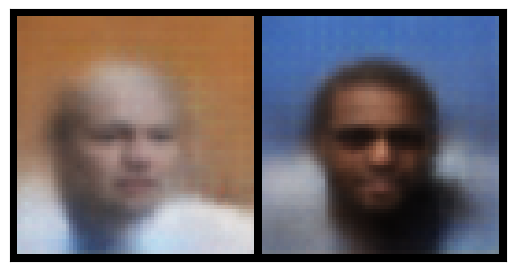

In [32]:
random_imgs = get_random_images_of_classes(dataset, [4, 4])
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing ebm geodesic: 100%|██████████| 1000/1000 [00:55<00:00, 18.03it/s, loss=1.32e+36]


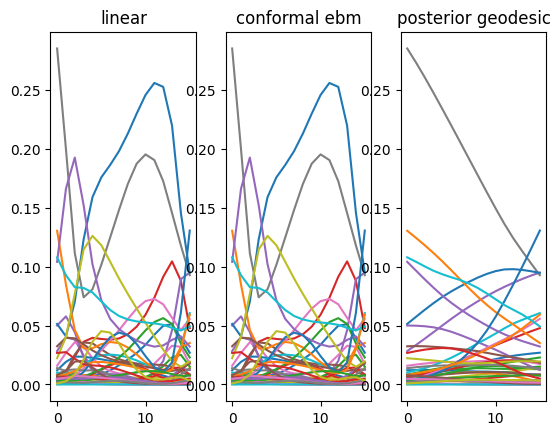

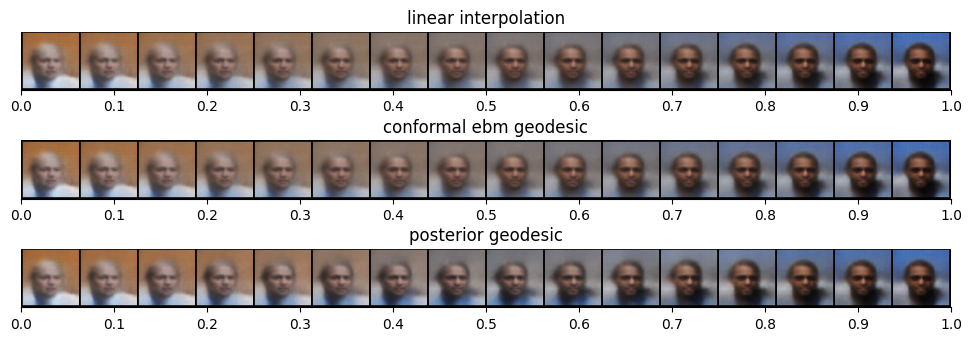

In [ ]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
ebm_geodesic = optimize_ebm_geodesic(*vae.encode(random_imgs), log_likelihood=log_likelihood, n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_ebm = torch.exp(log_posterior(ebm_geodesic.cuda()).cpu())
_, (axl, axm, axr) = plt.subplots(1, 3, figsize=(10, 6))
axl.plot(post_lin)
axl.set_title('linear')
axm.plot(post_ebm)
axm.set_title('conformal ebm')
axr.plot(post_geo)
axr.set_title('posterior geodesic')
plt.show()
_, (axu, axm, axb) = plt.subplots(3, 1, figsize=(12, 4))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(ebm_geodesic, 'conformal ebm geodesic', ax=axm)
show_latent_curve(geodesic, 'posterior geodesic', ax=axb)
plt.show()

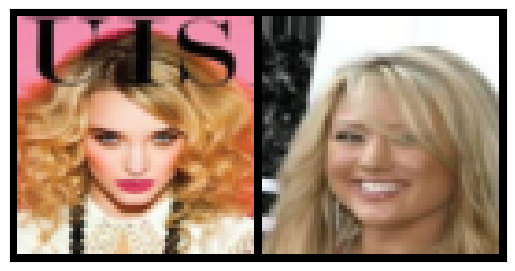

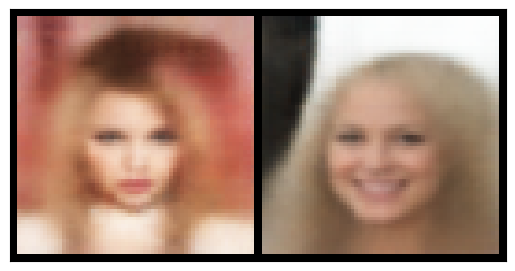

In [17]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing ebm geodesic: 100%|██████████| 1000/1000 [00:55<00:00, 17.94it/s, loss=-10.3]


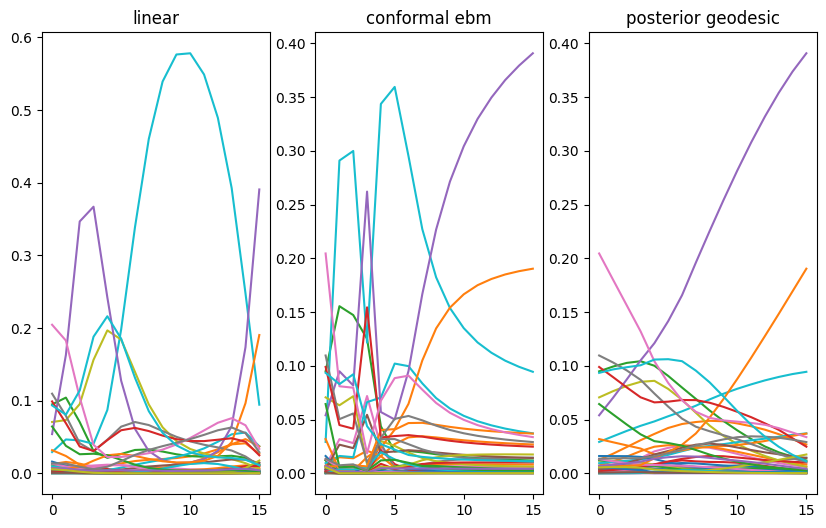

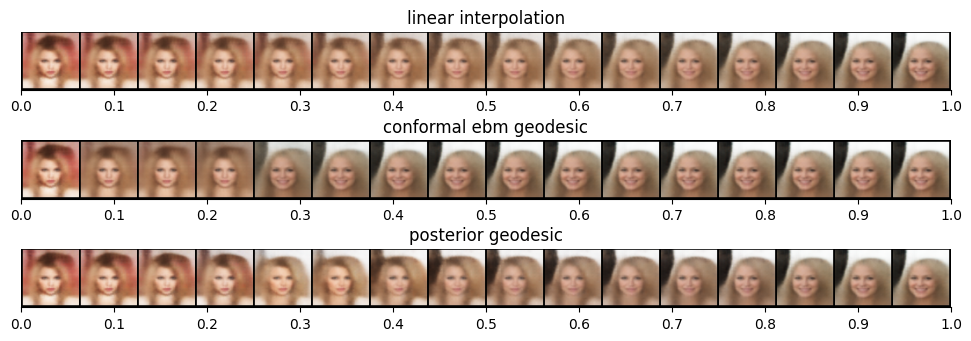

In [ ]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
ebm_geodesic = optimize_ebm_geodesic(*vae.encode(random_imgs), log_likelihood=log_likelihood, n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_ebm = torch.exp(log_posterior(ebm_geodesic.cuda()).cpu())
_, (axl, axm, axr) = plt.subplots(1, 3, figsize=(10, 4))
axl.plot(post_lin)
axl.set_title('linear')
axm.plot(post_ebm)
axm.set_title('conformal ebm')
axr.plot(post_geo)
axr.set_title('posterior geodesic')
plt.show()
_, (axu, axm, axb) = plt.subplots(3, 1, figsize=(12, 4))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(ebm_geodesic, 'conformal ebm geodesic', ax=axm)
show_latent_curve(geodesic, 'posterior geodesic', ax=axb)
plt.show()

In [30]:
k=7
least_common_indices = attribute_counts.sort().indices[:k]
print(*[f'{i} {attribute_names[i]} [{int(attribute_counts[i])}]' for i in least_common_indices], sep=', ')

4 Bald [4547], 22 Mustache [8417], 17 Gray_Hair [8499], 26 Pale_Skin [8701], 14 Double_Chin [9459], 35 Wearing_Hat [9818], 10 Blurry [10312]


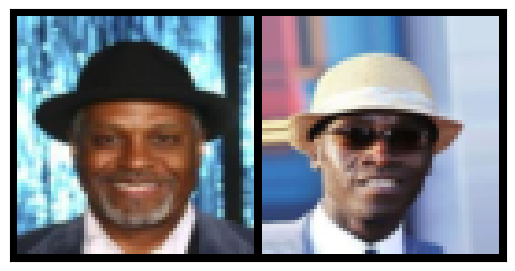

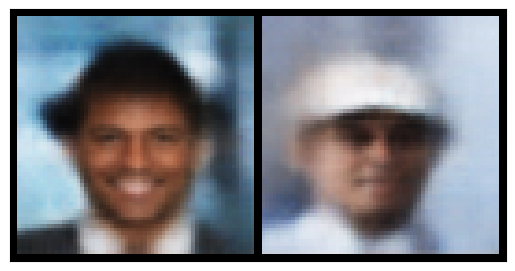

In [53]:
random_imgs = torch.stack((
    random_imgs[0],
    get_random_image_of_class(dataset, 35)
))
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing ebm geodesic: 100%|██████████| 1000/1000 [00:55<00:00, 17.97it/s, loss=-8.87]


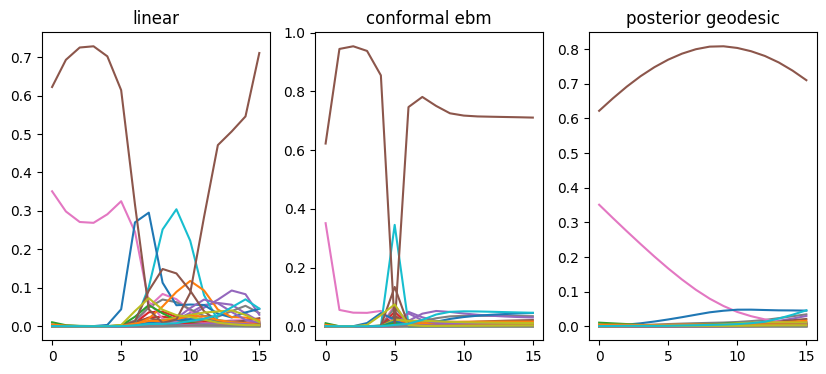

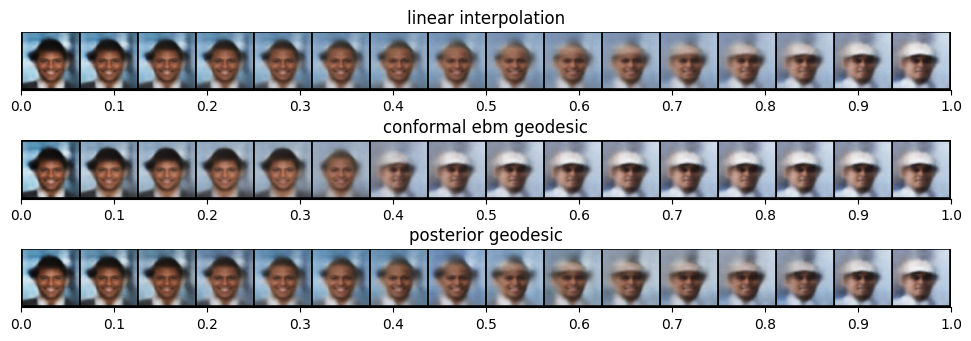

In [54]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
ebm_geodesic = optimize_ebm_geodesic(*vae.encode(random_imgs), log_likelihood=log_likelihood, n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_ebm = torch.exp(log_posterior(ebm_geodesic.cuda()).cpu())
_, (axl, axm, axr) = plt.subplots(1, 3, figsize=(10, 4))
axl.plot(post_lin)
axl.set_title('linear')
axm.plot(post_ebm)
axm.set_title('conformal ebm')
axr.plot(post_geo)
axr.set_title('posterior geodesic')
plt.show()
_, (axu, axm, axb) = plt.subplots(3, 1, figsize=(12, 4))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(ebm_geodesic, 'conformal ebm geodesic', ax=axm)
show_latent_curve(geodesic, 'posterior geodesic', ax=axb)
plt.show()

https://huggingface.co/eugenesiow/drln/resolve/main/pytorch_model_4x.pt


/net/st1/export/clusterhome/robertwiebe/testvenv/lib/python3.11/site-packages/super_image/modeling_utils.py:247: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = t

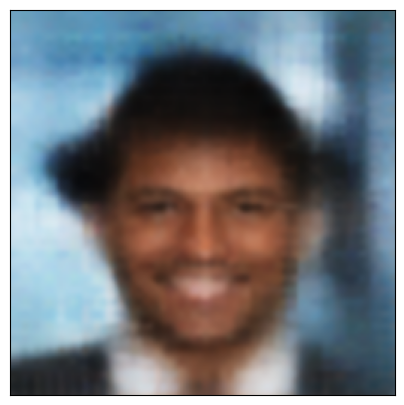

In [ ]:
from super_image import EdsrModel, ImageLoader, DrlnModel
from PIL import Image
image = Image.open("hat_guy.png")
# model = EdsrModel.from_pretrained('eugenesiow/edsr-base', scale=4)
model = DrlnModel.from_pretrained('eugenesiow/drln', scale=4)
inputs = ImageLoader.load_image(image)  #type:ignore
preds = model(inputs)

with torch.no_grad():
    preds = model(inputs)
show_img(preds[0], figsize=(5, 5))

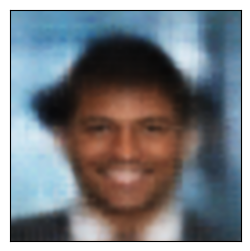

In [95]:
show_img(preds[0], figsize=(3, 3))

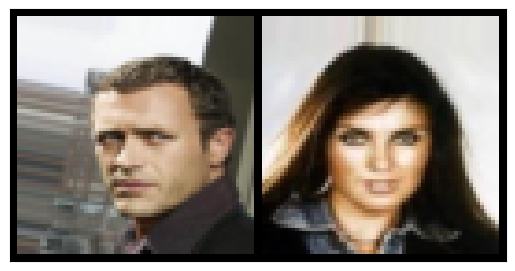

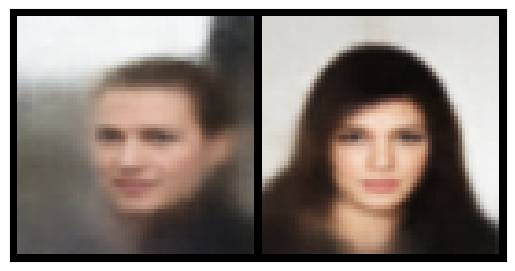

In [16]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing ebm geodesic: 100%|██████████| 1000/1000 [00:55<00:00, 17.89it/s, loss=-4.45]


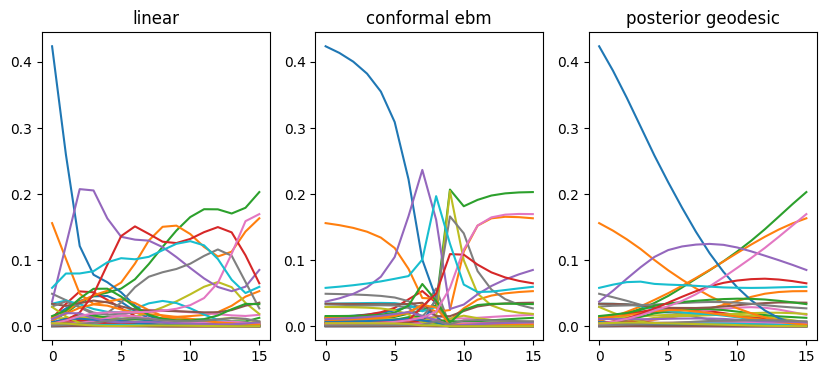

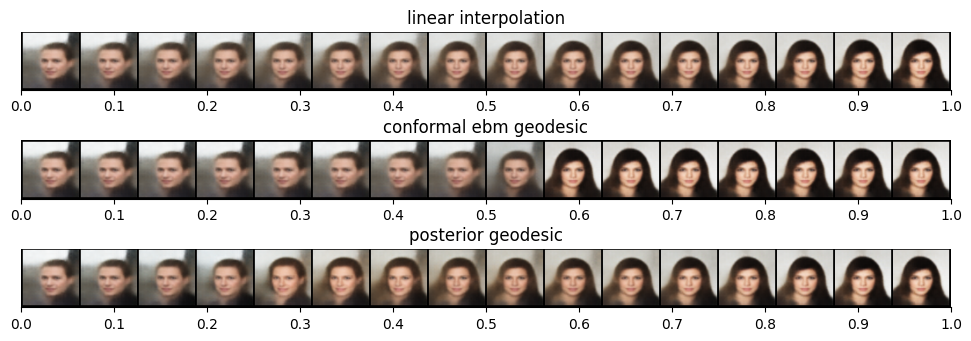

In [17]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
ebm_geodesic = optimize_ebm_geodesic(*vae.encode(random_imgs), log_likelihood=log_likelihood, n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_ebm = torch.exp(log_posterior(ebm_geodesic.cuda()).cpu())
_, (axl, axm, axr) = plt.subplots(1, 3, figsize=(10, 4))
axl.plot(post_lin)
axl.set_title('linear')
axm.plot(post_ebm)
axm.set_title('conformal ebm')
axr.plot(post_geo)
axr.set_title('posterior geodesic')
plt.show()
_, (axu, axm, axb) = plt.subplots(3, 1, figsize=(12, 4))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(ebm_geodesic, 'conformal ebm geodesic', ax=axm)
show_latent_curve(geodesic, 'posterior geodesic', ax=axb)
plt.show()

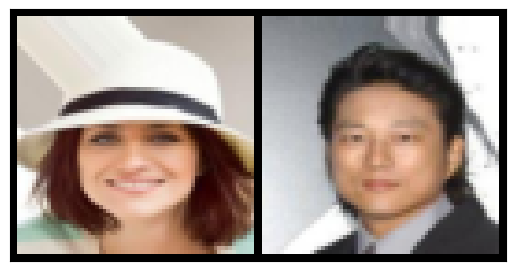

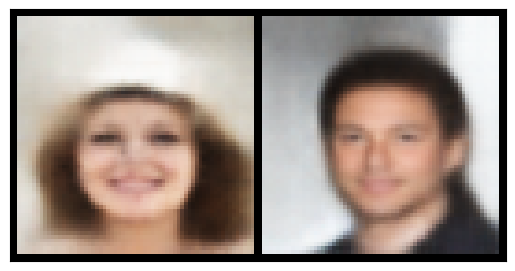

In [22]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing ebm geodesic: 100%|██████████| 1000/1000 [00:55<00:00, 18.17it/s, loss=-5.6]


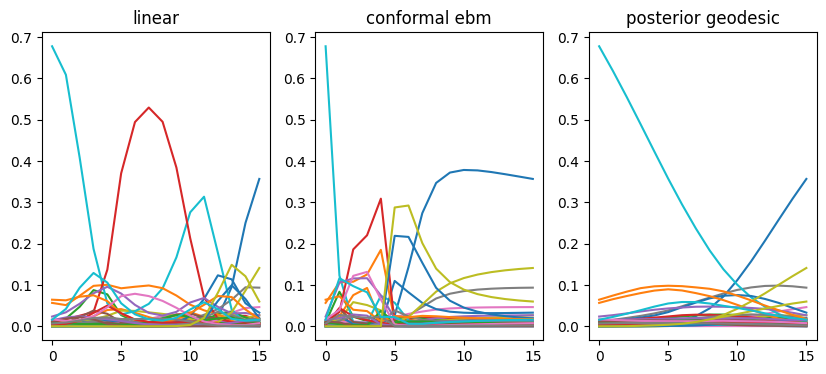

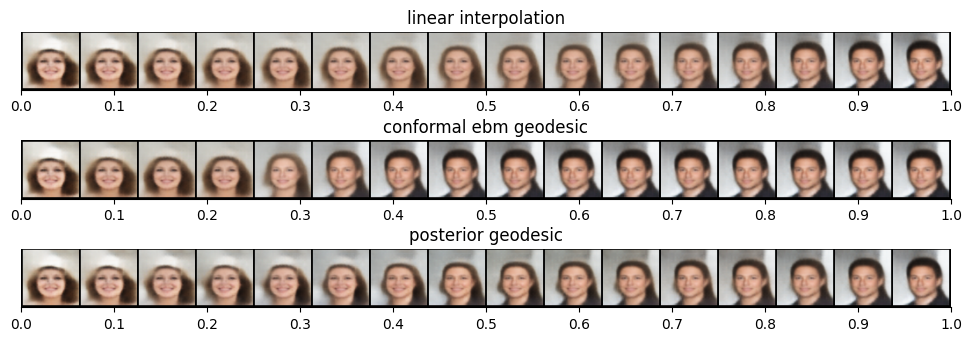

In [23]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
ebm_geodesic = optimize_ebm_geodesic(*vae.encode(random_imgs), log_likelihood=log_likelihood, n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_ebm = torch.exp(log_posterior(ebm_geodesic.cuda()).cpu())
_, (axl, axm, axr) = plt.subplots(1, 3, figsize=(10, 4))
axl.plot(post_lin)
axl.set_title('linear')
axm.plot(post_ebm)
axm.set_title('conformal ebm')
axr.plot(post_geo)
axr.set_title('posterior geodesic')
plt.show()
_, (axu, axm, axb) = plt.subplots(3, 1, figsize=(12, 4))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(ebm_geodesic, 'conformal ebm geodesic', ax=axm)
show_latent_curve(geodesic, 'posterior geodesic', ax=axb)
plt.show()

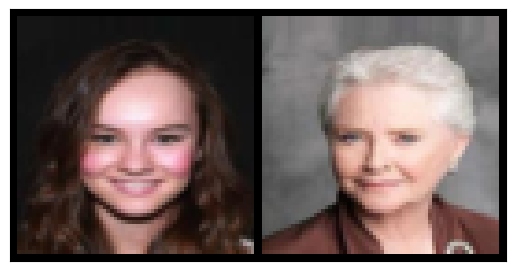

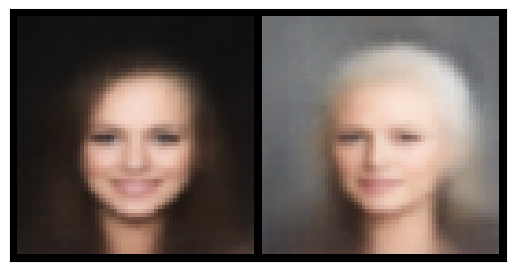

In [28]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing ebm geodesic: 100%|██████████| 1000/1000 [00:54<00:00, 18.26it/s, loss=8.27]


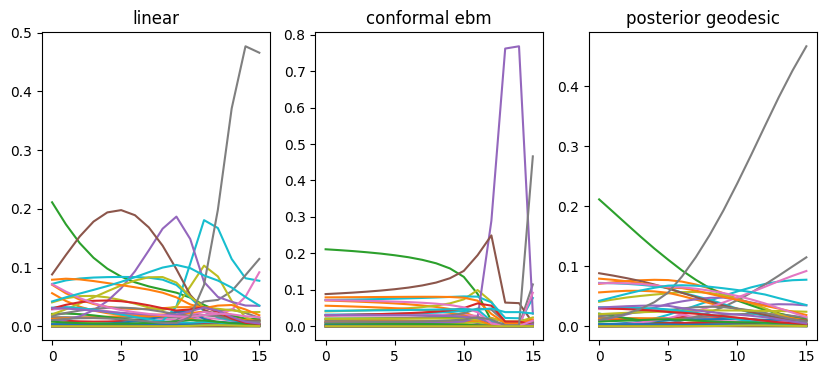

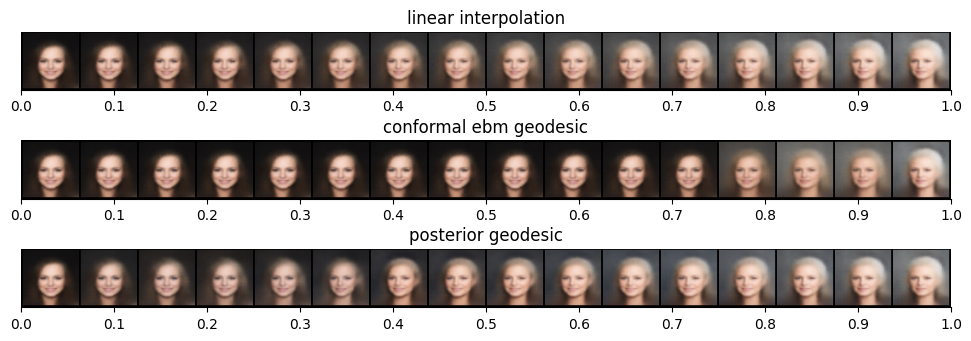

In [29]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
ebm_geodesic = optimize_ebm_geodesic(*vae.encode(random_imgs), log_likelihood=log_likelihood, n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_ebm = torch.exp(log_posterior(ebm_geodesic.cuda()).cpu())
_, (axl, axm, axr) = plt.subplots(1, 3, figsize=(10, 4))
axl.plot(post_lin)
axl.set_title('linear')
axm.plot(post_ebm)
axm.set_title('conformal ebm')
axr.plot(post_geo)
axr.set_title('posterior geodesic')
plt.show()
_, (axu, axm, axb) = plt.subplots(3, 1, figsize=(12, 4))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(ebm_geodesic, 'conformal ebm geodesic', ax=axm)
show_latent_curve(geodesic, 'posterior geodesic', ax=axb)
plt.show()

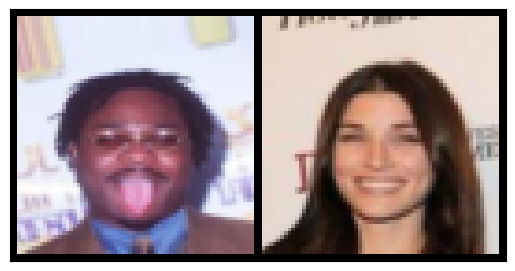

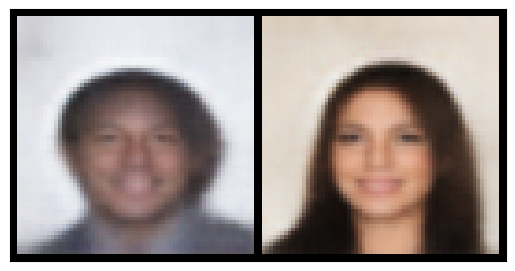

In [35]:
random_imgs = get_random_images(dataset, n=2)
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing ebm geodesic: 100%|██████████| 1000/1000 [00:54<00:00, 18.24it/s, loss=-5.16]


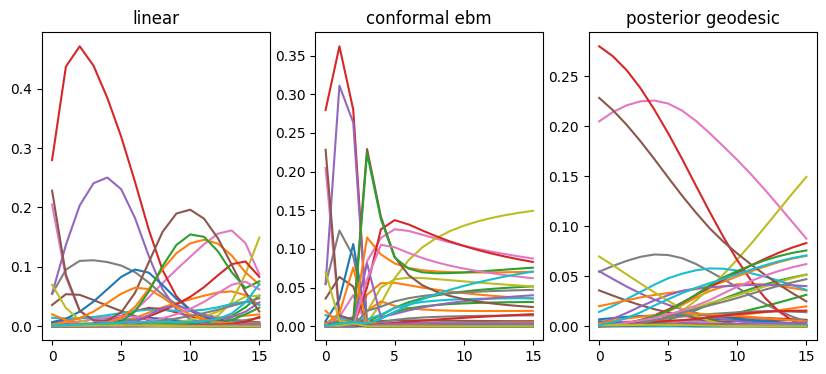

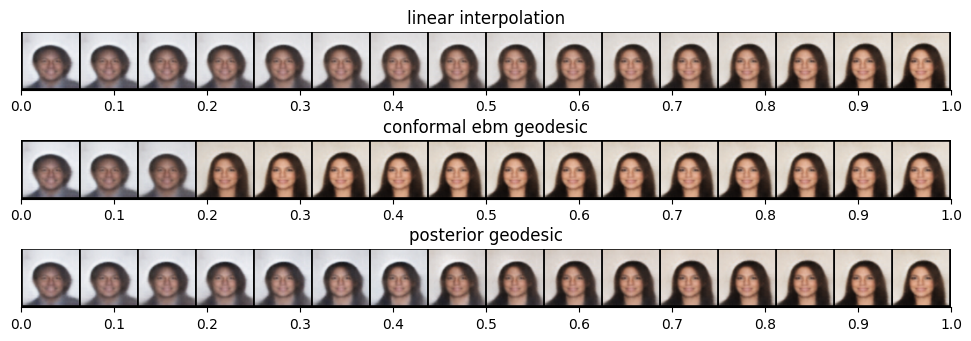

In [36]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
ebm_geodesic = optimize_ebm_geodesic(*vae.encode(random_imgs), log_likelihood=log_likelihood, n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_ebm = torch.exp(log_posterior(ebm_geodesic.cuda()).cpu())
_, (axl, axm, axr) = plt.subplots(1, 3, figsize=(10, 4))
axl.plot(post_lin)
axl.set_title('linear')
axm.plot(post_ebm)
axm.set_title('conformal ebm')
axr.plot(post_geo)
axr.set_title('posterior geodesic')
plt.show()
_, (axu, axm, axb) = plt.subplots(3, 1, figsize=(12, 4))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(ebm_geodesic, 'conformal ebm geodesic', ax=axm)
show_latent_curve(geodesic, 'posterior geodesic', ax=axb)
plt.show()

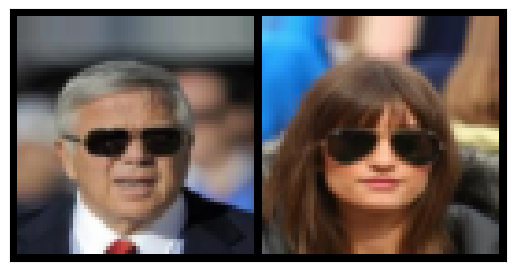

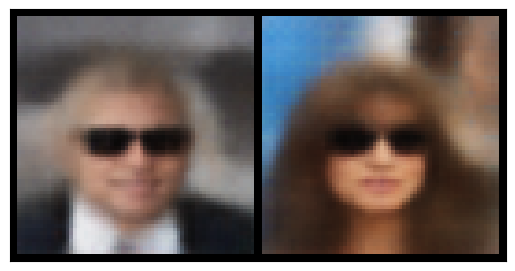

In [71]:
random_imgs = torch.stack((
    random_imgs[0],
    get_random_image_of_class(dataset, 15)
))
show_img(make_grid(random_imgs))
show_img(make_grid(vae.reconstruct(random_imgs)))

optimizing ebm geodesic: 100%|██████████| 1000/1000 [00:55<00:00, 17.92it/s, loss=4.61]


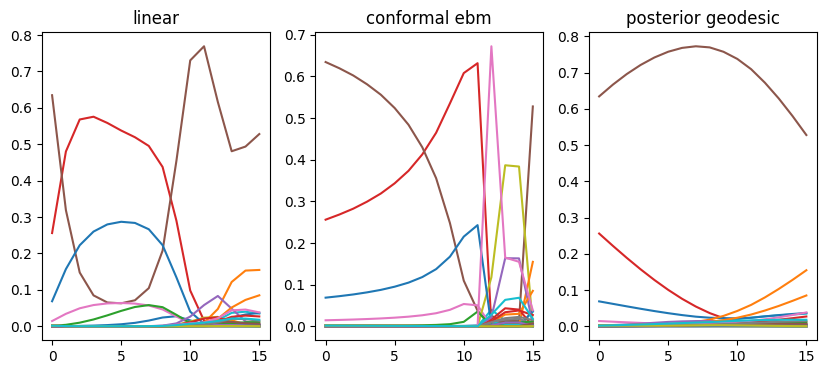

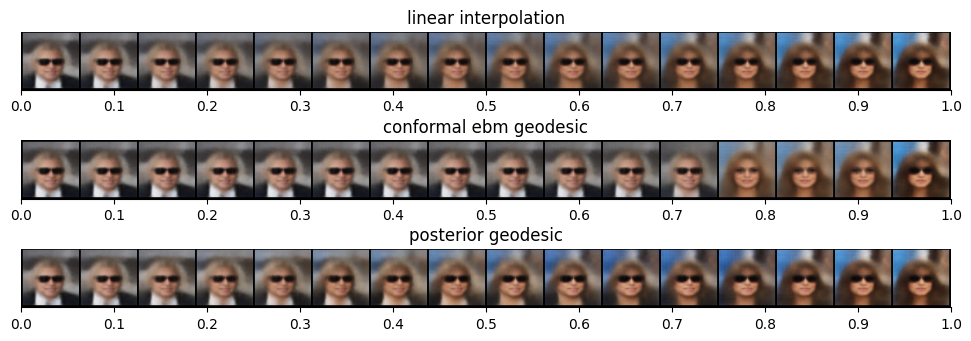

In [72]:
geodesic = M.optimize_geodesic(*vae.encode(random_imgs), n_segments=16, n_iter=1000)
ebm_geodesic = optimize_ebm_geodesic(*vae.encode(random_imgs), log_likelihood=log_likelihood, n_segments=16, n_iter=1000)
linline = lerp(*vae.encode(random_imgs), n=16)
with torch.no_grad():
    post_lin = torch.exp(log_posterior(linline.cuda()).cpu())
    post_geo = torch.exp(log_posterior(geodesic.cuda()).cpu())
    post_ebm = torch.exp(log_posterior(ebm_geodesic.cuda()).cpu())
_, (axl, axm, axr) = plt.subplots(1, 3, figsize=(10, 4))
axl.plot(post_lin)
axl.set_title('linear')
axm.plot(post_ebm)
axm.set_title('conformal ebm')
axr.plot(post_geo)
axr.set_title('posterior geodesic')
plt.show()
_, (axu, axm, axb) = plt.subplots(3, 1, figsize=(12, 4))
show_latent_curve(linline, 'linear interpolation', ax=axu)
show_latent_curve(ebm_geodesic, 'conformal ebm geodesic', ax=axm)
show_latent_curve(geodesic, 'posterior geodesic', ax=axb)
plt.show()